In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [3]:
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# Univariate Analysis

In [4]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<Axes: xlabel='Spending Score (1-100)', ylabel='Density'>

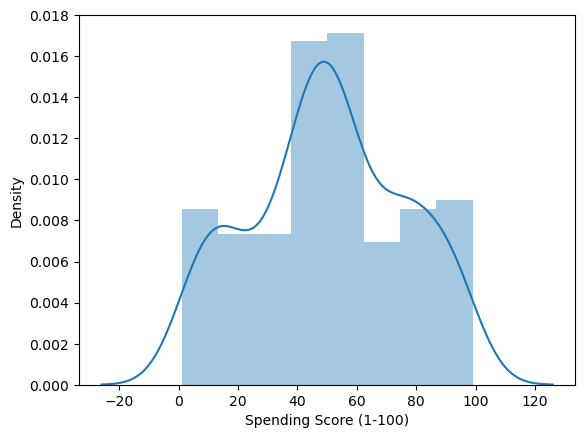

In [5]:
sns.distplot(df['Spending Score (1-100)'])

<Axes: xlabel='CustomerID', ylabel='Density'>

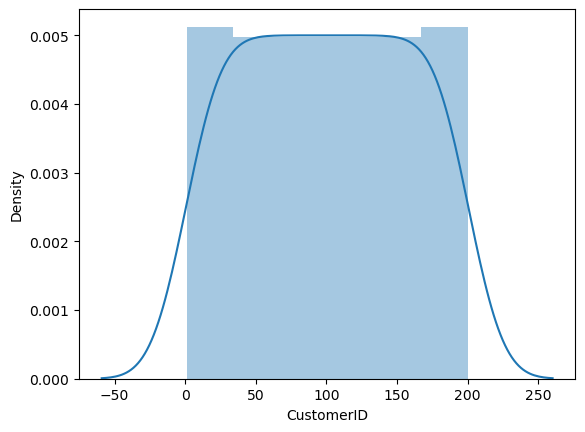

In [6]:
sns.distplot(df['CustomerID'])

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

### All Dist Plots in one frame

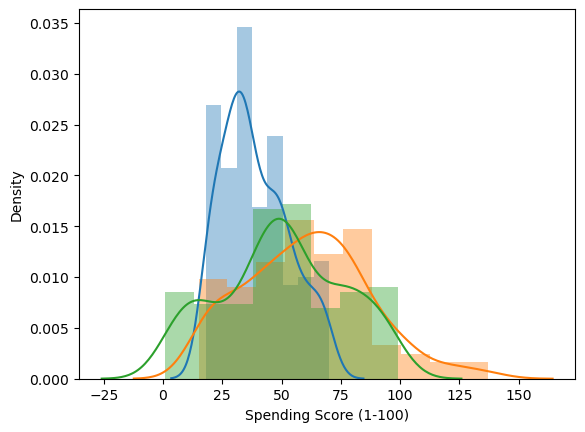

In [8]:
columns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for i in columns:
    sns.distplot(df[i])

### All Dist Plots in different frames

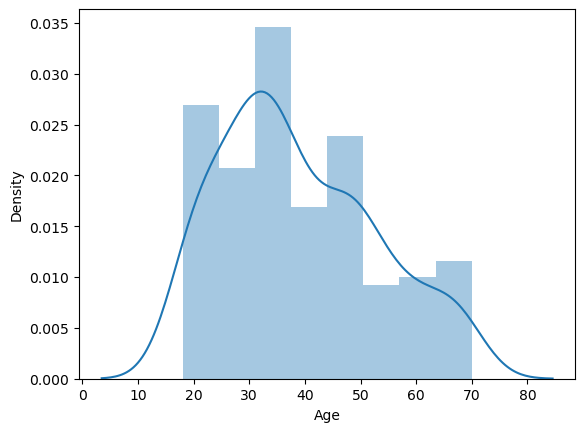

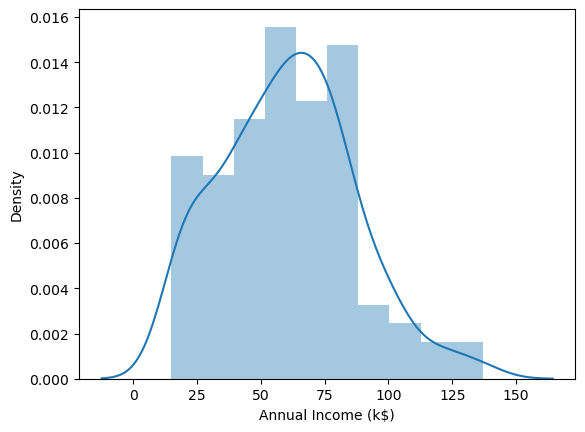

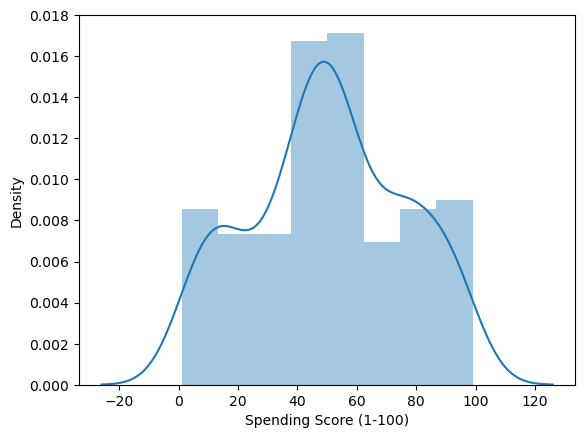

In [9]:
for i in columns:
    plt.figure()
    sns.distplot(df[i])

## Kernel Plot (k-distribution)

<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

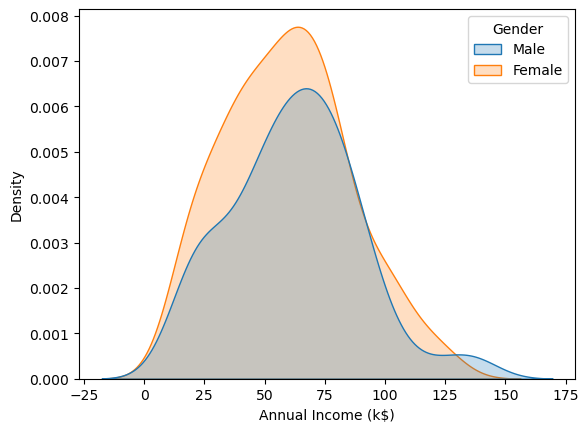

In [10]:
sns.kdeplot(data=df, x='Annual Income (k$)', fill=True, hue='Gender')

<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

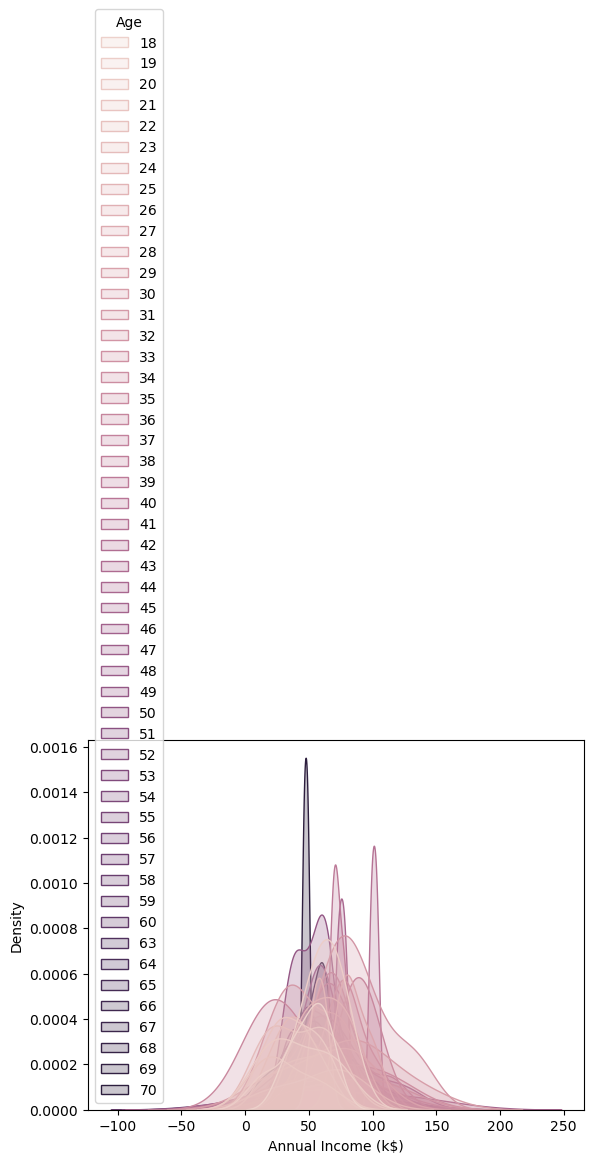

In [11]:
sns.kdeplot(data=df, x='Annual Income (k$)', fill=True, hue='Age')

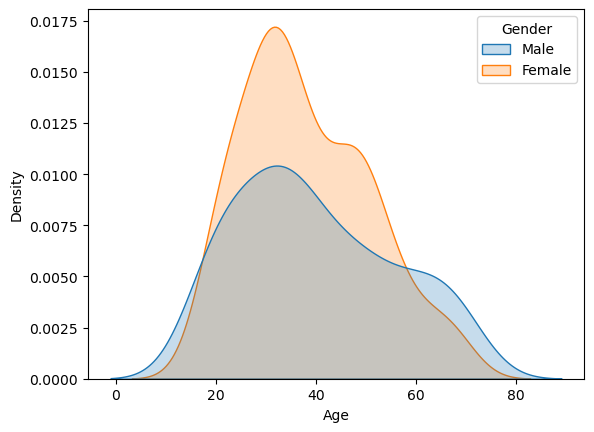

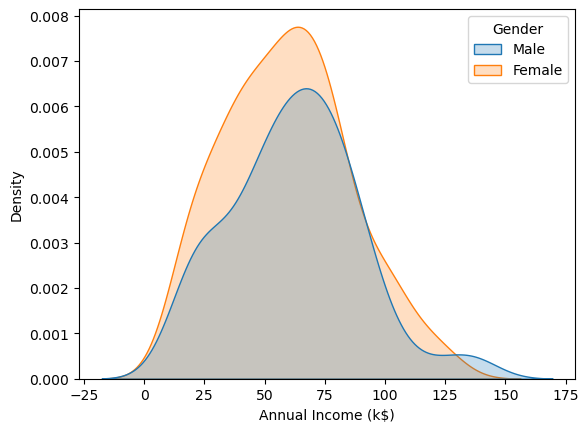

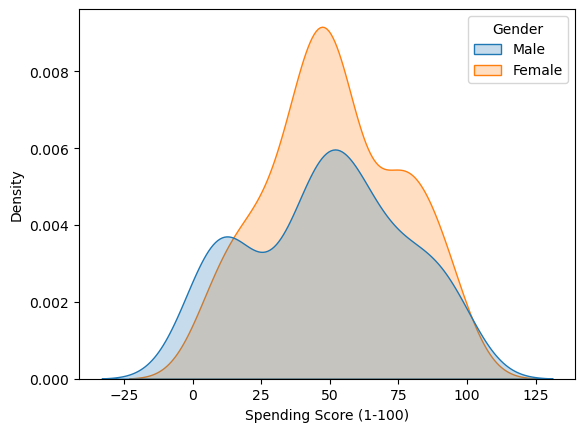

In [12]:
columns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for i in columns:
    plt.figure()
    sns.kdeplot(data=df, x=i, fill=True, hue='Gender')

## BOX PLOTS

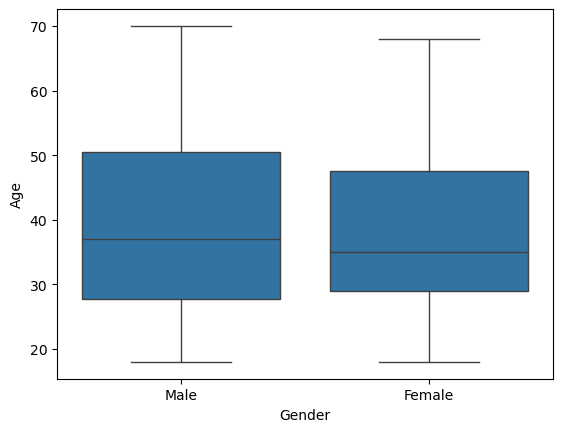

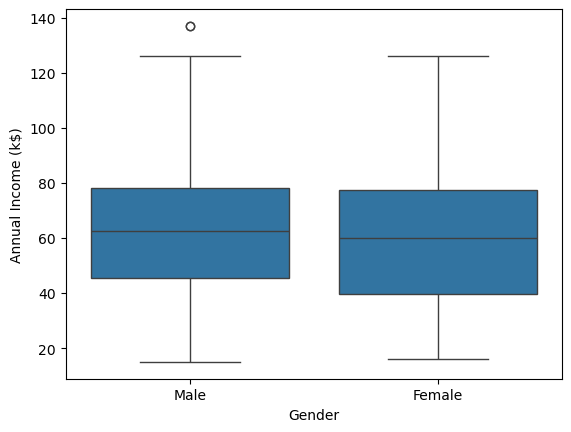

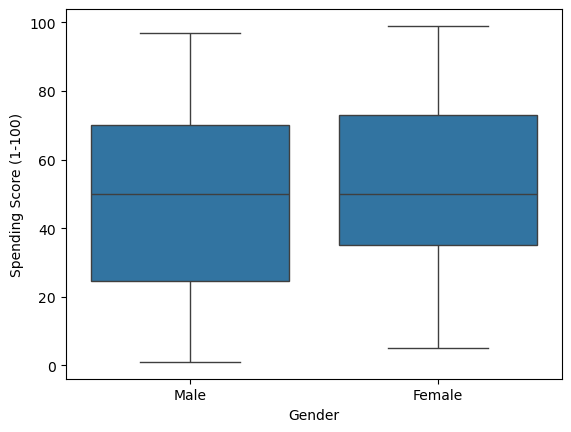

In [13]:
columns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for i in columns:
    plt.figure()
    sns.boxplot(data=df,x='Gender',y=i)

In [14]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [15]:
df['Gender'].value_counts(normalize = True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

In [16]:
df['Spending Score (1-100)'].value_counts(normalize = True)

Spending Score (1-100)
42    0.040
55    0.035
46    0.030
73    0.030
35    0.025
      ...  
31    0.005
44    0.005
53    0.005
65    0.005
18    0.005
Name: proportion, Length: 84, dtype: float64

# Bivaritate Analysis

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

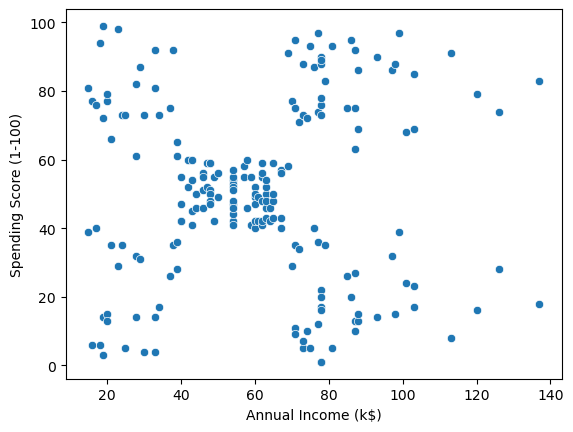

In [17]:
sns.scatterplot(data=df, x='Annual Income (k$)',y='Spending Score (1-100)' )

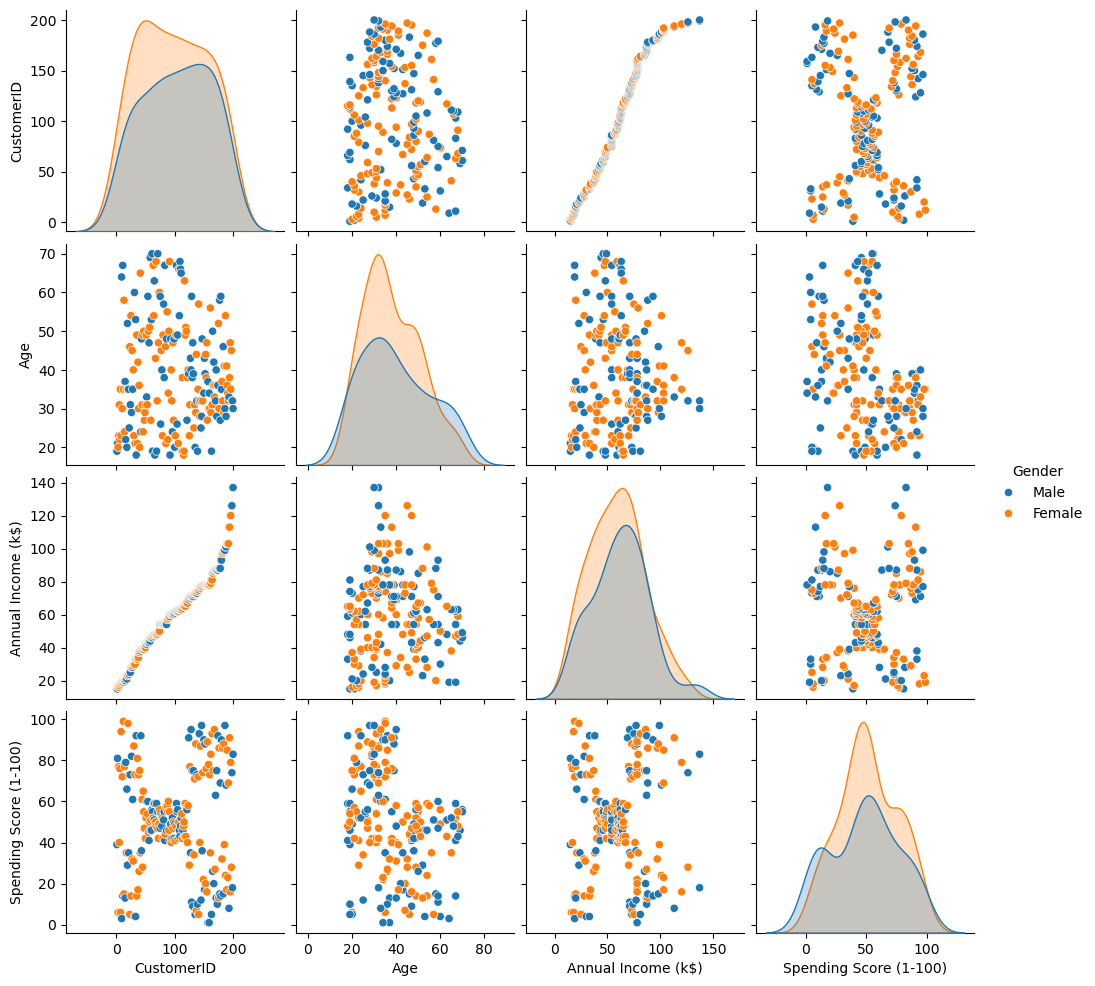

In [18]:
sns.pairplot(df,hue='Gender')

In [19]:
df.groupby('Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [20]:
df.groupby('Age')[[ 'Annual Income (k$)', 'Spending Score (1-100)']].mean().head(5)

,Annual Income (k$),Spending Score (1-100)
Age,,
18,51.250000,60.00
19,57.000000,39.75
20,41.600000,40.20
21,38.800000,66.80
22,31.333333,70.00


In [21]:
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
## “It shows how strongly Age, Income, and Spending Score are related to each other.”
## ✅ Example meanings:

# Age vs Income = 0.7
# → Older people tend to earn more

# Income vs Score = -0.4
# → Higher income → lower spending score

# Near 0
# → No clear relationship

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


<Axes: >

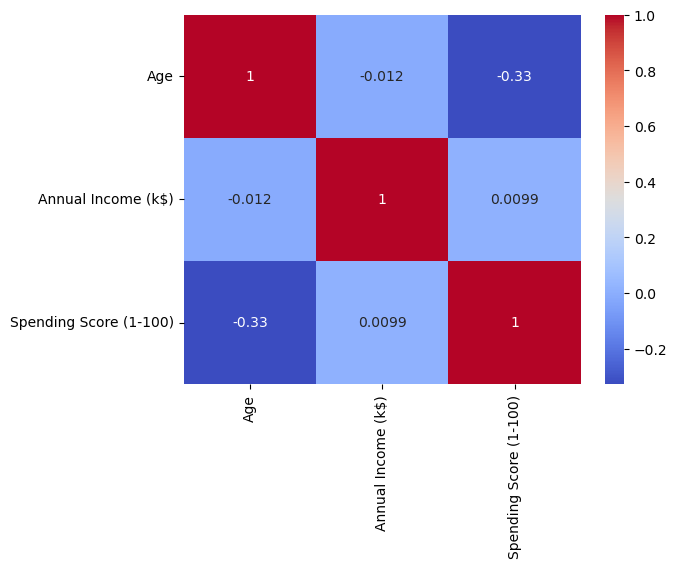

In [22]:
sns.heatmap(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(), annot=True,cmap='coolwarm')

# Clustering - Univariate, Bivariate, Multivariate

In [23]:
df[['Annual Income (k$)']]

,Annual Income (k$)
0,15
1,15
2,16
3,16
4,17
...,...
195,120
196,126
197,126
198,137


In [24]:
clustering1 = KMeans(n_clusters=7)

In [25]:
clustering1.fit(df[['Annual Income (k$)']])

,n_clusters,7
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [26]:
clustering1.labels_

array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 3, 3, 3, 3, 3, 3,
       3, 3], dtype=int32)

In [27]:
df['Income Cluster'] = clustering1.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,4
3,4,Female,23,16,77,4
4,5,Female,31,17,40,4


In [28]:
df['Income Cluster'].value_counts()

Income Cluster
0    48
1    42
5    40
4    32
2    18
6    12
3     8
Name: count, dtype: int64

In [29]:
intertia_scores=[]
for i in range(1,25):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(df[['Annual Income (k$)']])
    intertia_scores.append(kmeans.inertia_)

In [30]:
intertia_scores


[137277.28000000003,
 48660.88888888889,
 23517.330930930926,
 13757.071717171719,
 8667.679614837509,
 5496.533937621834,
 4328.7479949874705,
 2870.389589169001,
 2312.430982905983,
 1978.3973970473971,
 1461.2637029637028,
 1344.420634920635,
 911.2564935064935,
 824.3477633477634,
 690.6305860805861,
 629.6928571428571,
 638.5503968253969,
 474.3697691197691,
 405.78095238095244,
 370.4603174603175,
 295.17301587301586,
 219.05873015873016,
 210.7039682539683,
 196.04264069264076]

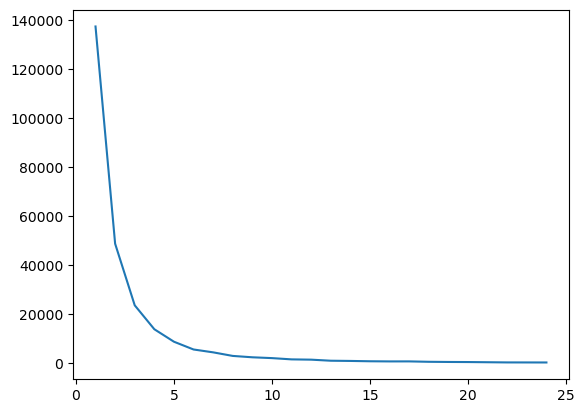

In [31]:
plt.plot(range(1,25),intertia_scores)

### As seen above, n = 10 is the ideal cluster size coz post that, it keeps slowing.

In [32]:
df.groupby('Income Cluster')[['Age', 'Annual Income (k$)',
       'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Income Cluster,,,
0,41.604167,60.083333,49.041667
1,43.000000,42.238095,50.666667
2,37.777778,86.888889,48.944444
3,36.500000,124.000000,49.625000
4,34.906250,22.000000,49.656250
5,35.950000,74.800000,51.200000
6,36.666667,100.166667,53.583333


# Bivariate Clustering

In [33]:
clustering2 = KMeans(n_clusters = 10)
clustering2.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
df['Spending and Income Cluster'] =clustering2.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,1,Male,19,15,39,4,1
1,2,Male,21,15,81,4,8
2,3,Female,20,16,6,4,5
3,4,Female,23,16,77,4,8
4,5,Female,31,17,40,4,1


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   CustomerID                   200 non-null    int64 
 1   Gender                       200 non-null    object
 2   Age                          200 non-null    int64 
 3   Annual Income (k$)           200 non-null    int64 
 4   Spending Score (1-100)       200 non-null    int64 
 5   Income Cluster               200 non-null    int32 
 6   Spending and Income Cluster  200 non-null    int32 
dtypes: int32(2), int64(4), object(1)
memory usage: 9.5+ KB


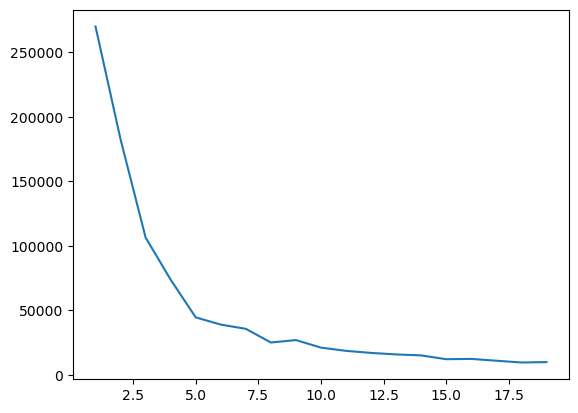

In [35]:
intertia_scores2=[]
for i in range(1,20):
    kmeans2=KMeans(n_clusters=i)
    kmeans2.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
    intertia_scores2.append(kmeans2.inertia_)
plt.plot(range(1,20),intertia_scores2)

In [36]:
clustering2.cluster_centers_

array([[ 78.03571429,  81.89285714],
       [ 30.        ,  34.61538462],
       [109.7       ,  22.        ],
       [ 26.66666667,  93.66666667],
       [ 48.1       ,  52.675     ],
       [ 24.58333333,   9.58333333],
       [108.18181818,  82.72727273],
       [ 80.18181818,  12.68181818],
       [ 24.46666667,  74.6       ],
       [ 63.72093023,  46.1627907 ]])

In [37]:
centers =pd.DataFrame(clustering2.cluster_centers_)

In [38]:
centers

,0,1
0,78.035714,81.892857
1,30.000000,34.615385
2,109.700000,22.000000
3,26.666667,93.666667
4,48.100000,52.675000
5,24.583333,9.583333
6,108.181818,82.727273
7,80.181818,12.681818
8,24.466667,74.600000
9,63.720930,46.162791


In [39]:
centers.columns

RangeIndex(start=0, stop=2, step=1)

In [40]:
centers.columns = ['x','y']

In [41]:
centers.columns

Index(['x', 'y'], dtype='object')

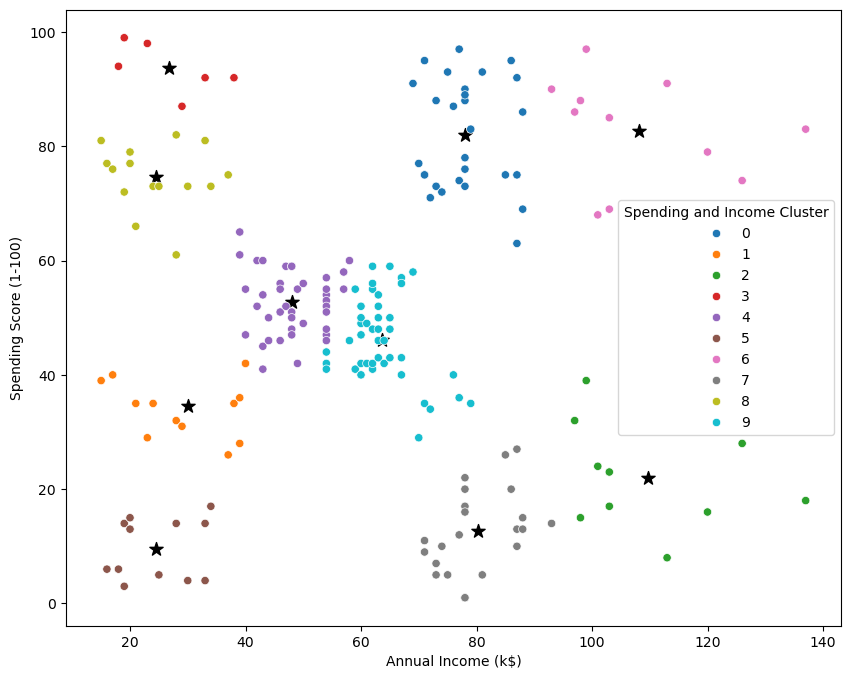

In [44]:

plt.figure(figsize=(10,8))
plt.scatter(x=centers['x'],y=centers['y'],s=100,c='black',marker='*')
sns.scatterplot(data=df, x ='Annual Income (k$)',y='Spending Score (1-100)',hue='Spending and Income Cluster',palette='tab10')
plt.savefig('clustering_bivaraiate.png')

In [46]:
pd.crosstab(df['Spending and Income Cluster'],df['Gender'])

Gender,Female,Male
Spending and Income Cluster,,
0,15,13
1,9,4
2,7,3
3,4,2
4,23,17
5,7,5
6,6,5
7,7,15
8,8,7


In [47]:
pd.crosstab(df['Spending and Income Cluster'],df['Gender'],normalize='index')

Gender,Female,Male
Spending and Income Cluster,,
0,0.535714,0.464286
1,0.692308,0.307692
2,0.700000,0.300000
3,0.666667,0.333333
4,0.575000,0.425000
5,0.583333,0.416667
6,0.545455,0.454545
7,0.318182,0.681818
8,0.533333,0.466667


In [48]:
df.groupby('Spending and Income Cluster')[['Age', 'Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending and Income Cluster,,,
0,32.785714,78.035714,81.892857
1,39.615385,30.000000,34.615385
2,41.000000,109.700000,22.000000
3,26.333333,26.666667,93.666667
4,43.975000,48.100000,52.675000
5,48.750000,24.583333,9.583333
6,32.454545,108.181818,82.727273
7,41.000000,80.181818,12.681818
8,24.933333,24.466667,74.600000


# Mulivariate Clustering

In [49]:
from sklearn.preprocessing import StandardScaler

In [50]:
scale = StandardScaler()

In [51]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,1,Male,19,15,39,4,1
1,2,Male,21,15,81,4,8
2,3,Female,20,16,6,4,5
3,4,Female,23,16,77,4,8
4,5,Female,31,17,40,4,1


In [52]:
dff = pd.get_dummies(df,drop_first=True)
dff.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster,Gender_Male
0,1,19,15,39,4,1,True
1,2,21,15,81,4,8,True
2,3,20,16,6,4,5,False
3,4,23,16,77,4,8,False
4,5,31,17,40,4,1,False


In [53]:
dff.columns

Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Income Cluster', 'Spending and Income Cluster', 'Gender_Male'],
      dtype='object')

In [54]:
dff = dff[['Age', 'Annual Income (k$)', 'Spending Score (1-100)','Gender_Male']]
dff.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


In [56]:
dff = scale.fit_transform(dff)

In [58]:
dff

array([[-1.42456879, -1.73899919, -0.43480148,  1.12815215],
       [-1.28103541, -1.73899919,  1.19570407,  1.12815215],
       [-1.3528021 , -1.70082976, -1.71591298, -0.88640526],
       [-1.13750203, -1.70082976,  1.04041783, -0.88640526],
       [-0.56336851, -1.66266033, -0.39597992, -0.88640526],
       [-1.20926872, -1.66266033,  1.00159627, -0.88640526],
       [-0.27630176, -1.62449091, -1.71591298, -0.88640526],
       [-1.13750203, -1.62449091,  1.70038436, -0.88640526],
       [ 1.80493225, -1.58632148, -1.83237767,  1.12815215],
       [-0.6351352 , -1.58632148,  0.84631002, -0.88640526],
       [ 2.02023231, -1.58632148, -1.4053405 ,  1.12815215],
       [-0.27630176, -1.58632148,  1.89449216, -0.88640526],
       [ 1.37433211, -1.54815205, -1.36651894, -0.88640526],
       [-1.06573534, -1.54815205,  1.04041783, -0.88640526],
       [-0.13276838, -1.54815205, -1.44416206,  1.12815215],
       [-1.20926872, -1.54815205,  1.11806095,  1.12815215],
       [-0.27630176, -1.